In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parents[0]  # importing functions from other folders
sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from _data.data_utils import read_in
# from _fitting.fitting_utils import hist_plot, CI_plot, CI_plot_alt, CI_plot_both, plot_posteriors_side_by_side, plot_spline_Bknots
import pymc as pm
import pymc.math as pmm
import arviz as az
from patsy import dmatrix
import nutpie
import time
from IPython.display import display
from pymc.variational.callbacks import CheckParametersConvergence
import io
import base64
import re

az.style.use("arviz-darkgrid")


if '___laptop' in os.listdir('../'):
    # laptop folder
    folder = "../../_data/p-dengue/"
elif '___server' in os.listdir('../'):
    # server folder
    folder = "../../../../../data/lucaratzinger_data/p_dengue/"

%matplotlib inline
import warnings
import seaborn as sns

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

---
## Weather-Statistic-Dependent Zero Proportions

In [2]:
data = read_in(folder, admin=2, max_lag=6, dropna=True, start_year=2016, start_month=1, end_year=2020, end_month=12)
# data.to_csv('weather_data.csv', index=False)
# data = pd.read_csv('weather_data.csv')

In [3]:
def plot_zero_proportion(data, stat_name, thresholds=None):
    if thresholds is None:
        thresholds = [0.8, 0.9, 0.95, 0.975, 0.99, 0.999]

    d = data.copy()
    stat_min, stat_max = np.min(d[stat_name]), np.max(d[stat_name])
    stat_vals = np.linspace(stat_min, stat_max, 1000)

    zero_prop = []
    for t in stat_vals:
        prop = np.mean(d.loc[d[stat_name] < t, 'cases'] == 0)
        zero_prop.append(prop)
    zero_prop = np.array(zero_prop)
    # Plot main curve
    plt.plot(stat_vals, zero_prop, lw=0.5)

    crossings = []
    cmap = plt.cm.cool
    first_label = {t: True for t in thresholds}
    # Detect threshold crossings
    for i, t in enumerate(thresholds):
        diff = zero_prop - t
        sign_change = np.where(np.diff(np.sign(diff)) != 0)[0]
        for idx in sign_change[1:]:
            x1, x2 = stat_vals[idx], stat_vals[idx+1]
            y1, y2 = zero_prop[idx], zero_prop[idx+1]

            x_cross = (x1+x2)/2

            crossings.append((t, x_cross, '▼' if np.sign(y2-t) < 0 else '▲'))

            color = cmap(i/len(thresholds))
            label = f"{t}" if first_label[t] else None
            first_label[t] = False

            plt.axvline(x_cross, alpha=0.6, color=color, lw=0.8, label=label)
    crossings_df = pd.DataFrame(crossings, columns=["threshold", stat_name, "direction"])
    crossings_df.dropna(inplace=True)
    crossings_df = crossings_df.sort_values([stat_name, "threshold"]).reset_index(drop=True)

    plt.xlabel(f'{stat_name} t', fontsize=12)
    plt.ylabel('Zero Proportion', fontsize=12)
    plt.title(f'Proportion of Zero Cases in Data with {stat_name} < t', fontsize=14)
    plt.grid()
    if len(crossings_df) > 0:
        plt.legend(title="threshold", fontsize=10)

    fig = plt.gcf()
    fig.set_dpi(250)

    return fig, crossings_df

In [4]:
def plot_mean(data, stat_name, nonzero=False):
    """
    Plot the mean of 'cases' as a function of a statistic threshold.

    Parameters
    ----------
    data : pd.DataFrame
        Data containing 'cases' and a column `stat_name`.
    stat_name : str
        Column name in `data` to threshold over.
    nonzero : bool
        If True, compute mean only over non-zero 'cases', else include all cases.
    """

    d = data.copy()
    stat_min, stat_max = np.min(d[stat_name]), np.max(d[stat_name])
    stat_vals = np.linspace(stat_min, stat_max, 1000)

    mean_vals = []
    for t in stat_vals:
        subset = d.loc[d[stat_name] < t, 'rate']
        if nonzero:
            subset = subset[subset != 0]
        mean_vals.append(subset.mean() if len(subset) > 0 else 0)
    mean_vals = np.array(mean_vals)

    # Plot main curve
    plt.plot(stat_vals, mean_vals, lw=1, color='blue')


    plt.xlabel(f'{stat_name} threshold t', fontsize=12)
    plt.ylabel('Mean Rate', fontsize=12)
    plt.title(f'Mean Rate vs {stat_name} < t', fontsize=14)
    plt.grid()

    fig = plt.gcf()
    fig.set_dpi(250)

    # Create a dataframe for the mean values
    mean_df = pd.DataFrame({
        stat_name: stat_vals,
        'mean_cases': mean_vals
    })

    return fig, mean_df

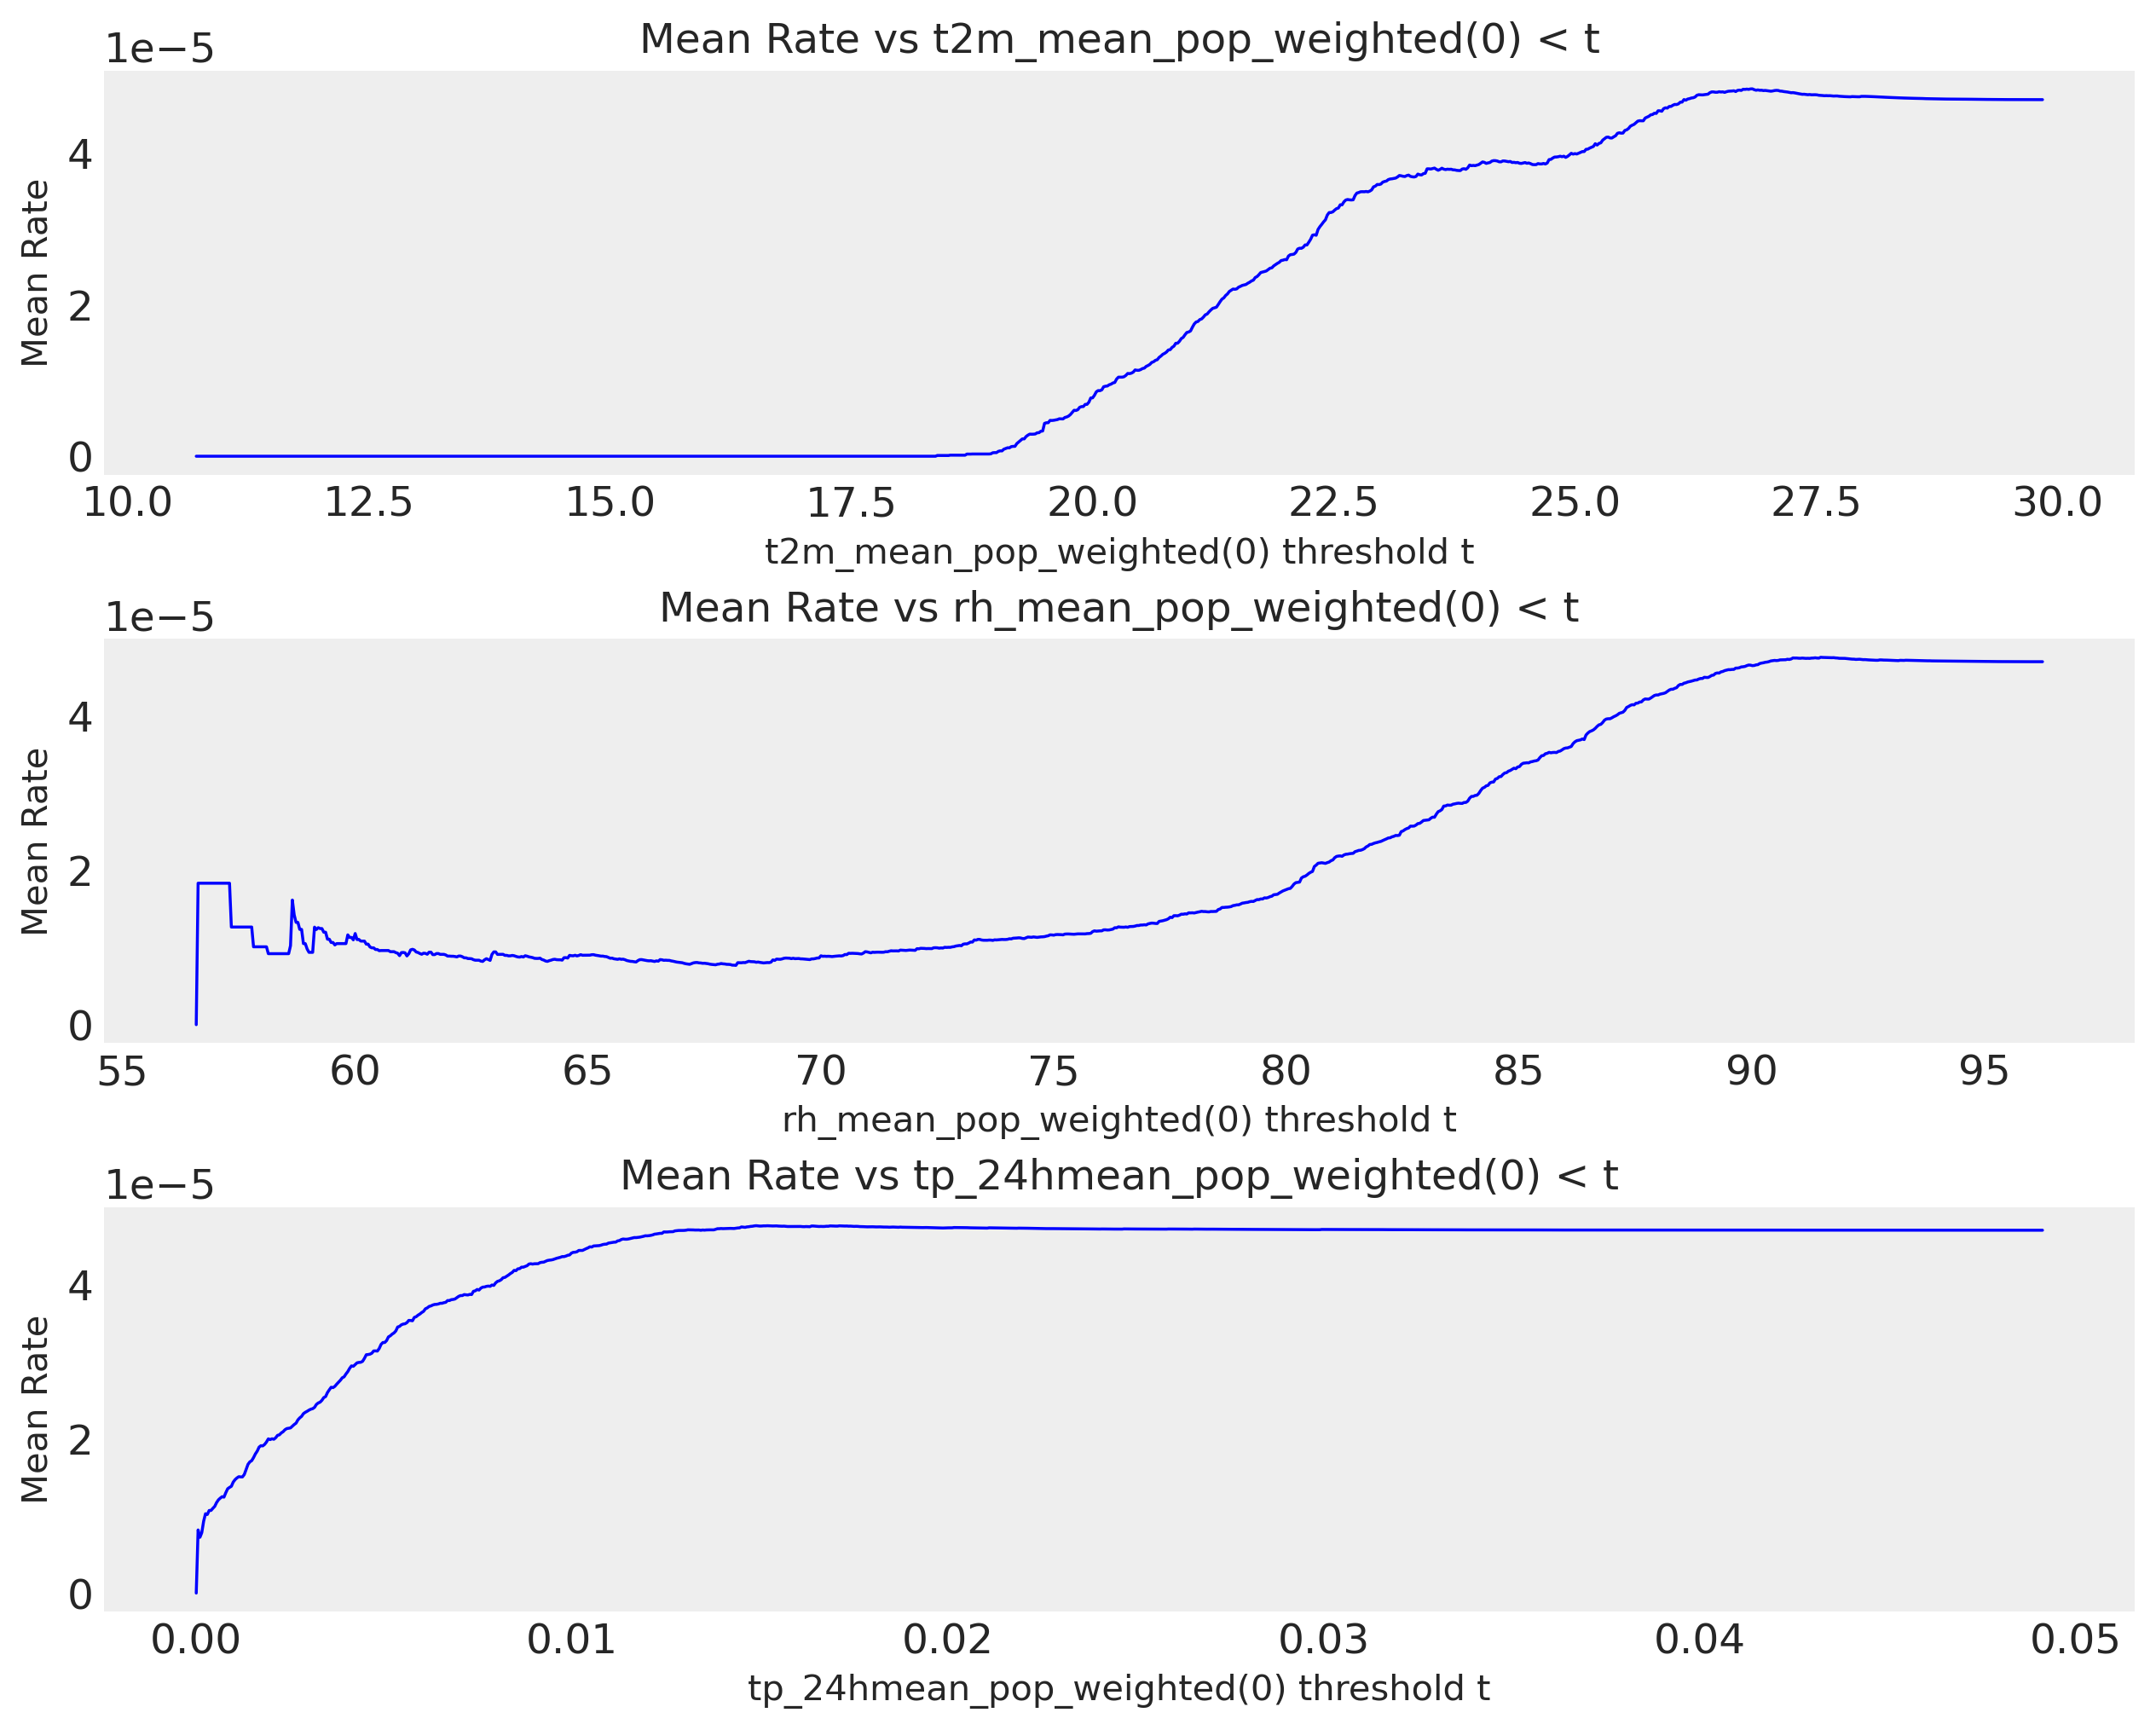

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8))

for ax, stat_name in zip(axes, ['t2m_mean_pop_weighted(0)', 'rh_mean_pop_weighted(0)', 'tp_24hmean_pop_weighted(0)']):
    plt.sca(ax)
    plot_mean(data, stat_name)
plt.show()

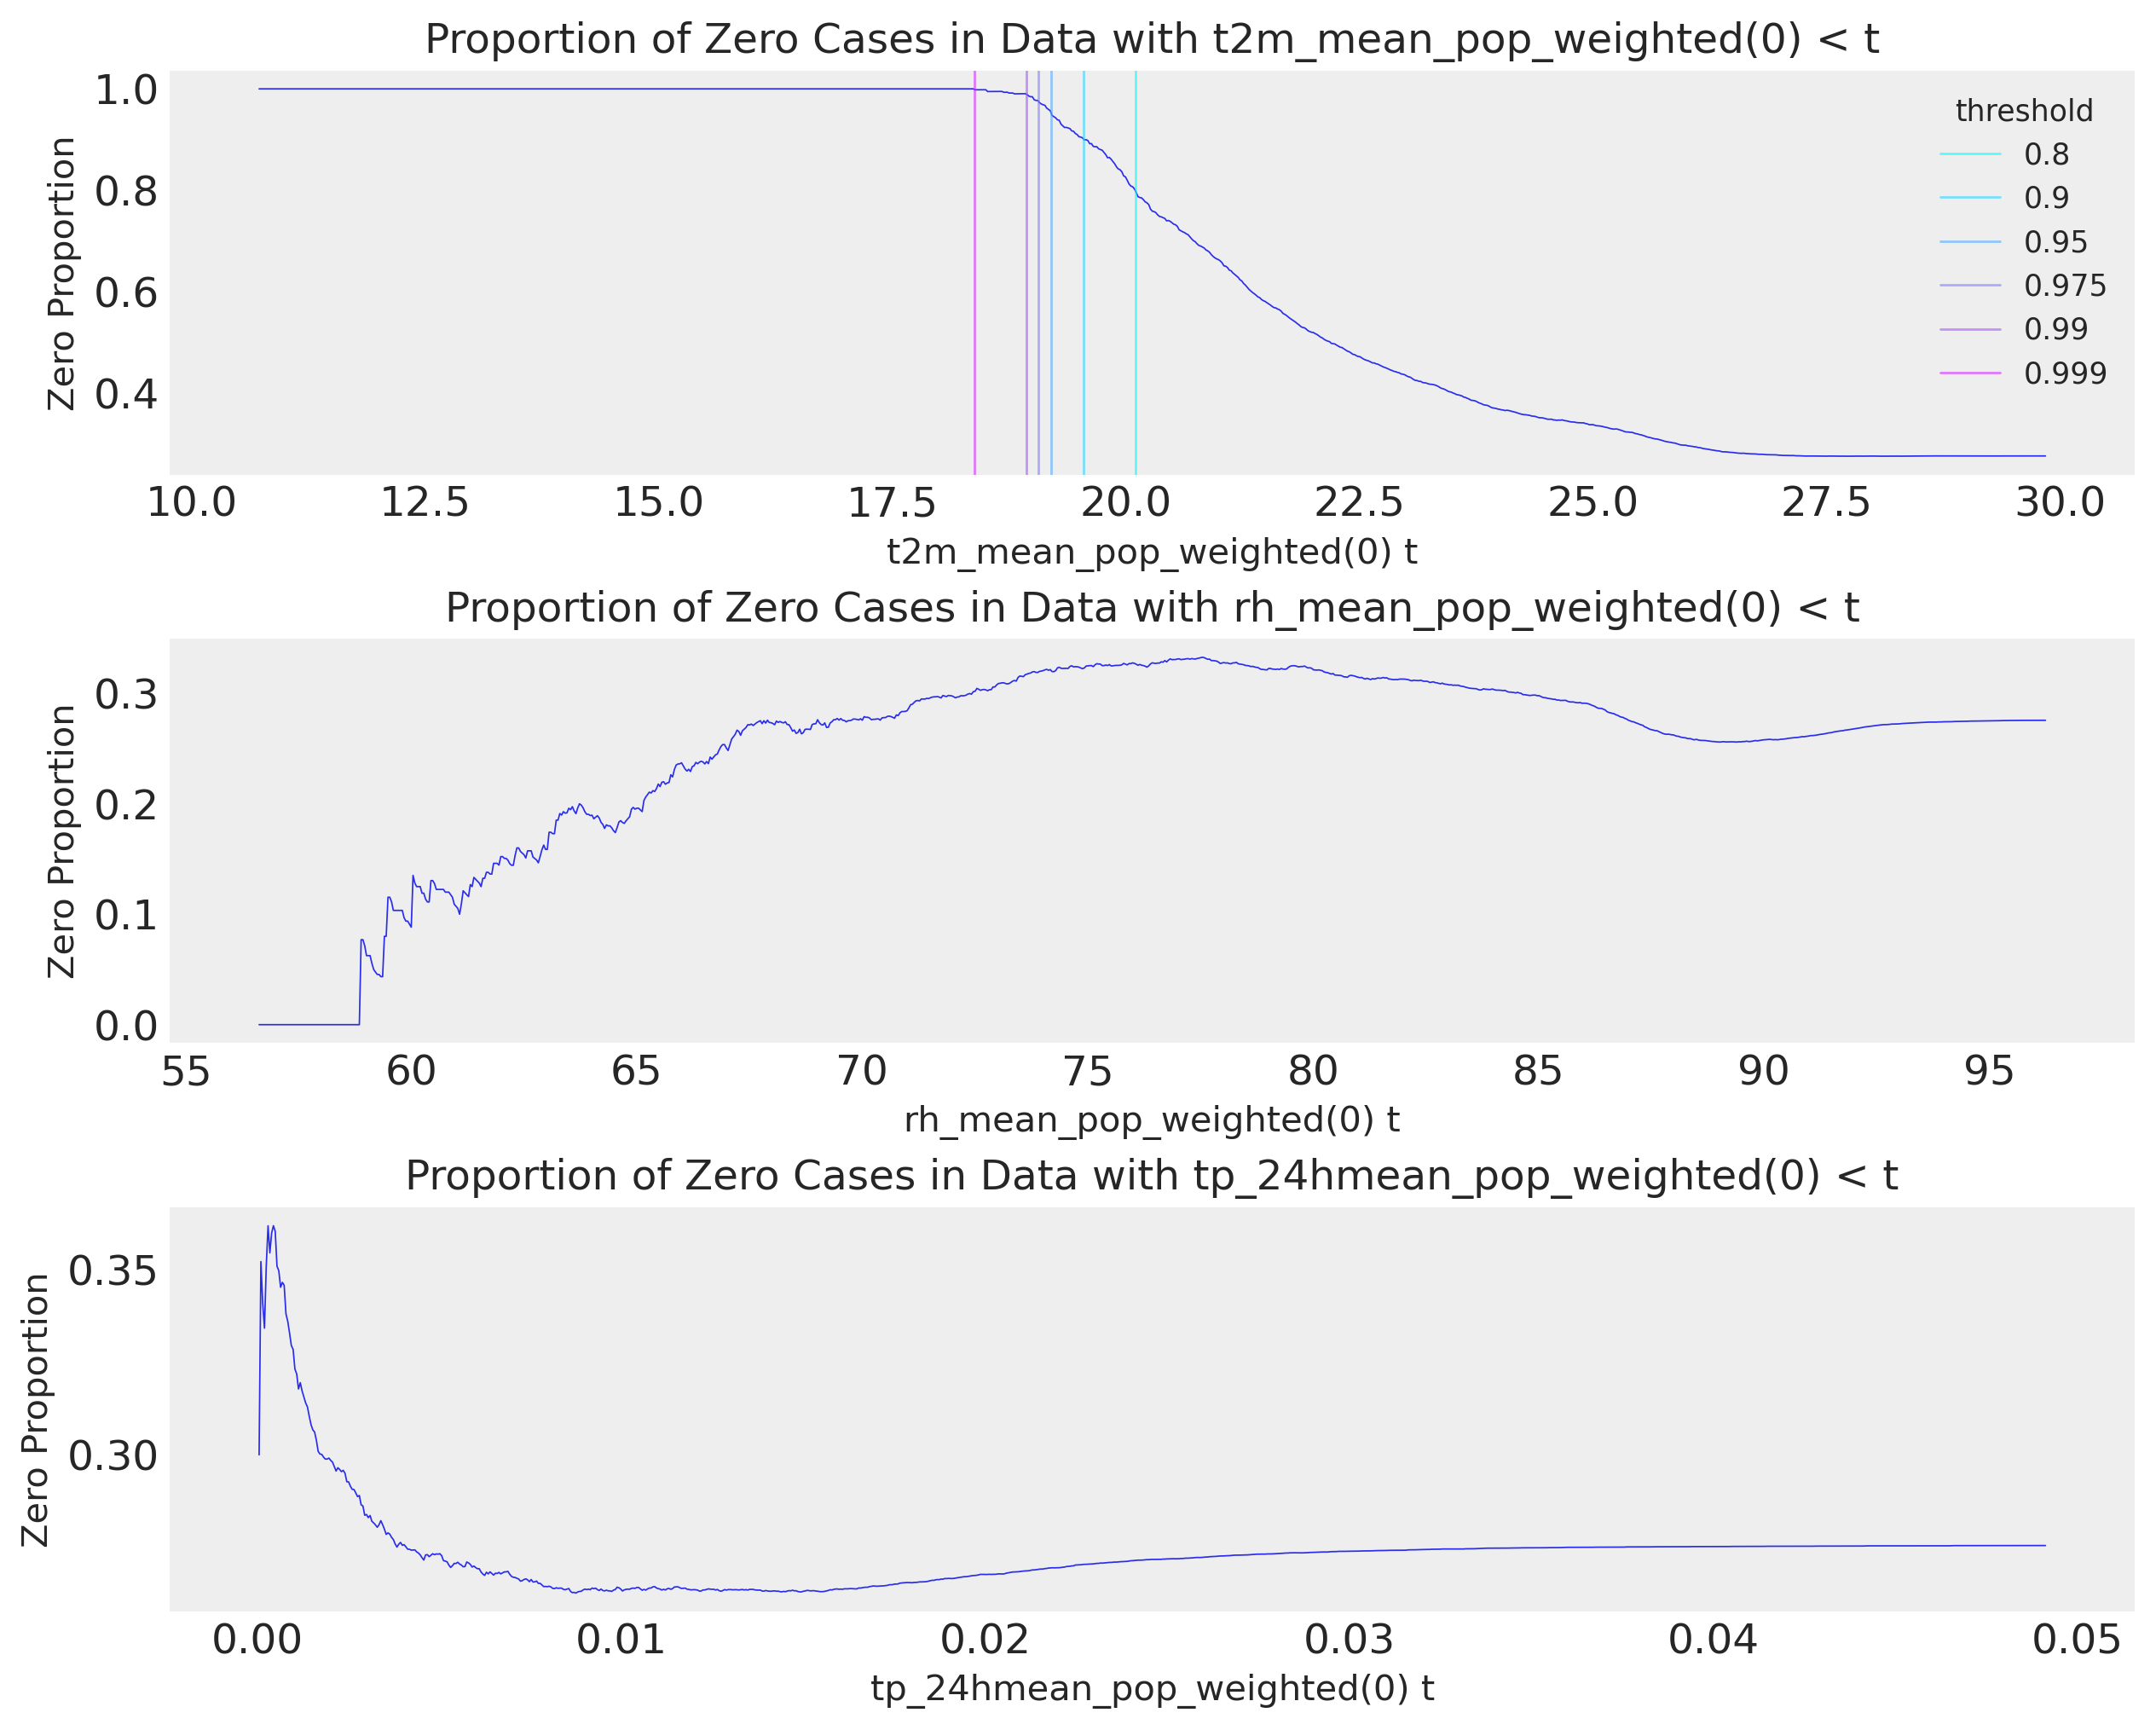

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8))

for ax, stat_name in zip(axes, ['t2m_mean_pop_weighted(0)', 'rh_mean_pop_weighted(0)', 'tp_24hmean_pop_weighted(0)']):
    plt.sca(ax)
    plot_zero_proportion(data, stat_name)
plt.show()

### Temperature shows a marked zero domain with strong suppression (proportion of zeros > 0.95) at 19.202

In [7]:
stat_name = 't2m_mean_pop_weighted(0)'
fig, crossings_df = plot_zero_proportion(data, stat_name)
plt.close()
display(crossings_df.round(3))

,threshold,t2m_mean_pop_weighted(0),direction
0,0.999,18.379,▼
1,0.990,18.934,▼
2,0.975,19.068,▼
3,0.950,19.202,▼
4,0.900,19.547,▼
5,0.800,20.103,▼


### We want to choose a cutoff where the spline in the log_mu of the count likelihood starts to explain the number of cases. Given the log link it struggles to push towards zero mean, and it is questionable that the count likelihood (poisson and negative binomial) is even appropriate to model all these zeroes. We can choose the cutoff where this happens, for example 19.00 degrees celsius. The sigmoid function (with a linear function of temperature as input) will handle the transition between the zero and non-zero domain and the spline will explain the behaviour in the non-zero domain.

---